In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [4]:
print("1. LOADING TITANIC DATASET")
# Load Titanic dataset 
df = pd.read_csv(r"/Users/pratikvilasgadhe/Desktop/Programming/AI_ML/titanic/train.csv")

1. LOADING TITANIC DATASET


In [5]:
print(f"Dataset Shape: {df.shape}")
print(df.head())

Dataset Shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

In [6]:
print("2. EXPLORATORY DATA ANALYSIS (EDA)")
# Dataset overview
print("\n--- Dataset Info ---")
df.info()

print("\n--- Missing Values Check ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

print("\n--- Duplicate Values Check ---")
duplicated_values = df.duplicated().sum()
print(duplicated_values[duplicated_values > 0])

print("\n--- Summary Statistics (Numerical Features) ---")
print(df.describe())

print("\n--- Summary Statistics (Object Features) ---")
print(df.describe(include=[object]))

print("\n--- Survival Rate by Passenger Class ---")
if "Pclass" in df.columns and "Survived" in df.columns:
    print(df.groupby("Pclass")["Survived"].mean())

2. EXPLORATORY DATA ANALYSIS (EDA)

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

--- Missing Values Check ---
Age         177
Cabin       687
Embarked      2
dtype: int64

--- Duplicate Values Check ---
[]

--- Summary Statistics (Numerical Features) ---
       PassengerId    Survi

/var/folders/gq/pn_jxryd2kv7467xp_wyc6v80000gn/T/ipykernel_18690/2109701262.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include=[object]))


3. DATA VISUALIZATION


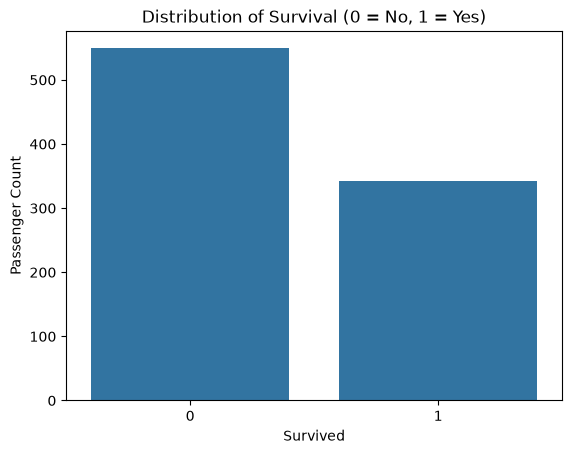

Saved: titanic_survival_count.png


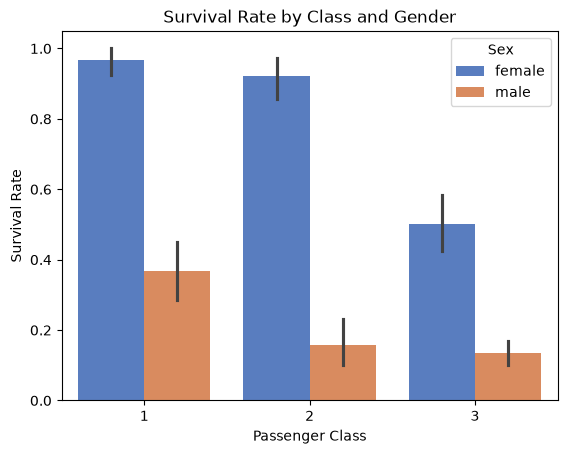

Saved: titanic_survival_by_class_sex.png


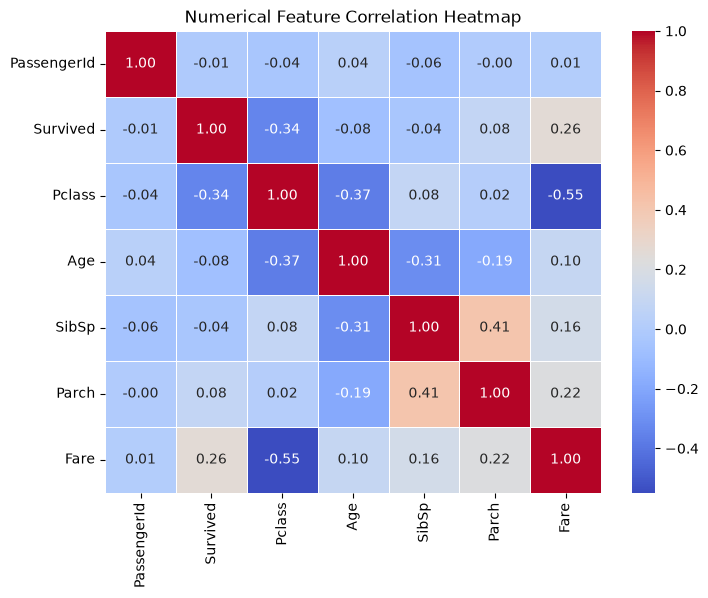

Saved: titanic_correlation_heatmap.png


In [7]:
print("3. DATA VISUALIZATION")
# 1. Survival Count Plot
plt.figure()
sns.countplot(data=df, x=df['Survived'])
plt.title("Distribution of Survival (0 = No, 1 = Yes)")
plt.xlabel("Survived")
plt.ylabel("Passenger Count")
plt.savefig("titanic_survival_count.png")
plt.show()
plt.close()
print("Saved: titanic_survival_count.png")

# 2. Survival Rate by Sex and Class
plt.figure()
sns.barplot(data=df, x=df['Pclass'], y=df['Survived'], hue=df['Sex'], palette="muted")
plt.title("Survival Rate by Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.savefig("titanic_survival_by_class_sex.png")
plt.show()
plt.close()
print("Saved: titanic_survival_by_class_sex.png")

# 3. Correlation Heatmap for Numerical Features
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Numerical Feature Correlation Heatmap")
plt.savefig("titanic_correlation_heatmap.png")
plt.show()
plt.close()
print("Saved: titanic_correlation_heatmap.png")

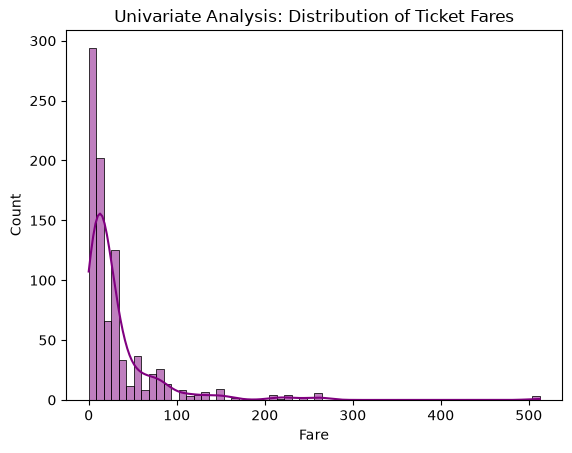

In [8]:
plt.figure()
sns.histplot(df["Fare"], kde=True, color="purple")
plt.title("Univariate Analysis: Distribution of Ticket Fares")
plt.savefig("univariate_fare.png")
plt.show()
plt.close()

/var/folders/gq/pn_jxryd2kv7467xp_wyc6v80000gn/T/ipykernel_18690/1349574683.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Survived", y="Age", palette="Set3")


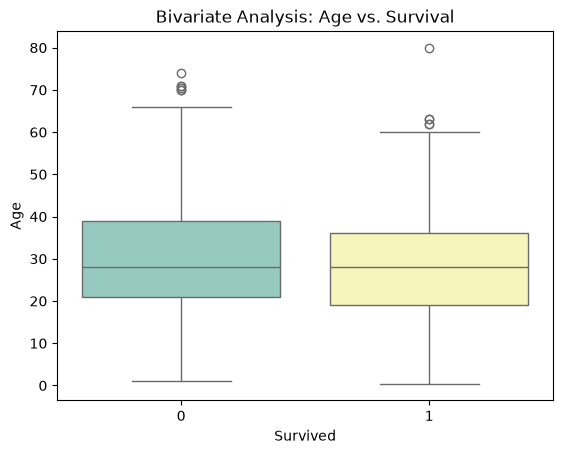

In [9]:
### 2. Bivariate Analysis (Examining Relationships Between Two Variables)
sns.boxplot(data=df, x="Survived", y="Age", palette="Set3")
plt.title("Bivariate Analysis: Age vs. Survival")
plt.savefig("bivariate_age_survival.png")
plt.show()
plt.close()

/var/folders/gq/pn_jxryd2kv7467xp_wyc6v80000gn/T/ipykernel_18690/192869958.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Survived", y="Fare", palette="Set3")


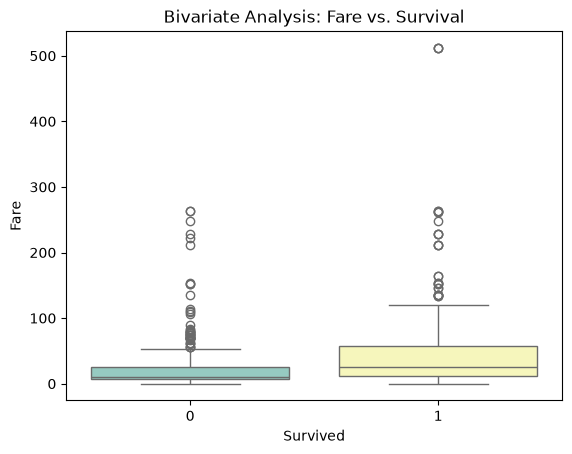

In [10]:
sns.boxplot(data=df, x="Survived", y="Fare", palette="Set3")
plt.title("Bivariate Analysis: Fare vs. Survival")
plt.savefig("bivariate_age_survival_1.png")
plt.show()
plt.close()

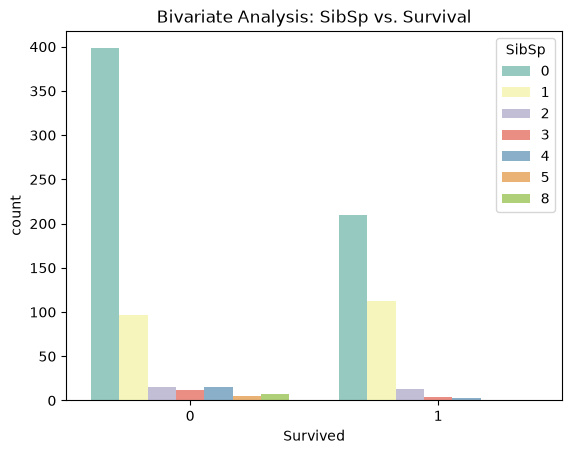

In [11]:
sns.countplot(data=df, x="Survived", hue="SibSp", palette="Set3")
plt.title("Bivariate Analysis: SibSp vs. Survival")
plt.savefig("bivariate_age_survival_SibSp.png")
plt.show()
plt.close()

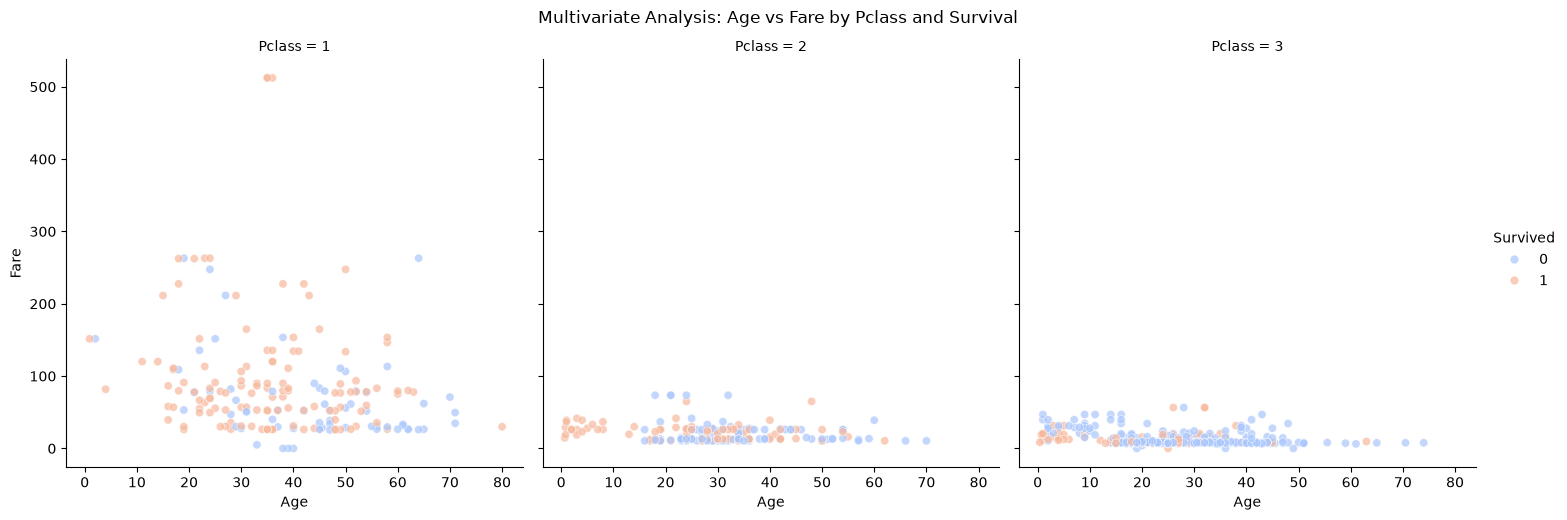

In [12]:
g = sns.relplot(data=df,    x="Age", y="Fare", hue="Survived", col="Pclass",kind="scatter",alpha=0.7,palette="coolwarm")
g.fig.suptitle("Multivariate Analysis: Age vs Fare by Pclass and Survival", y=1.03)
plt.savefig("multivariate_age_fare_pclass.png")
plt.show()
plt.close()

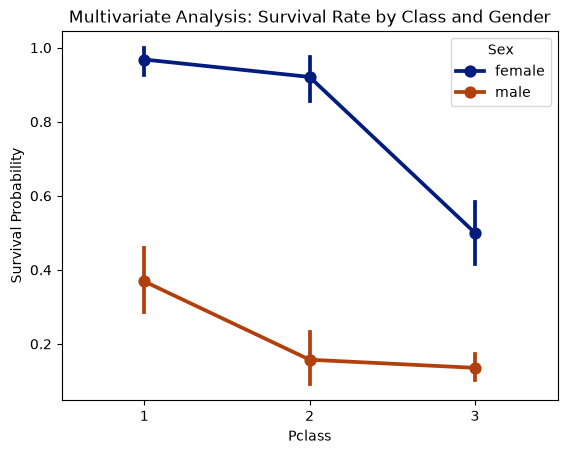

In [13]:
plt.figure()
sns.pointplot(data=df, x="Pclass", y="Survived", hue="Sex", palette="dark")
plt.title("Multivariate Analysis: Survival Rate by Class and Gender")
plt.ylabel("Survival Probability")
plt.savefig("multivariate_class_sex_survival.png")
plt.show()
plt.close()

In [14]:
print("4. FEATURE ENGINEERING & PREPROCESSING")

# Feature Engineering: Create Family Size and IsAlone features
df["family_size"] = df["SibSp"] + df["Parch"] + 1
df["is_alone"] = (df["family_size"] == 1).astype(int)

print("Engineered new features: 'family_size' and 'is_alone'")

# Drop columns with excessive missing data or redundant representations
# ('deck' has too many missing values; 'alive' is target duplicate; 'embark_town' mirrors 'embarked')
columns_to_drop = ["Cabin"]
df_cleaned = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Separate Features (X) and Target (y)
X = df_cleaned.drop(columns=["Survived"])
y = df_cleaned["Survived"]

# Identify numerical and categorical features
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print(f"\nNumerical Columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical Columns ({len(categorical_cols)}): {categorical_cols}")

# Build preprocessing pipelines
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

# Combine preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

# Apply preprocessing transformations
X_processed = preprocessor.fit_transform(X)

print(f"\nFinal Processed Feature Matrix Shape: {X_processed.shape}")
print("Data Preprocessing and Feature Engineering Completed Successfully!")

4. FEATURE ENGINEERING & PREPROCESSING
Engineered new features: 'family_size' and 'is_alone'

Numerical Columns (8): ['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'family_size', 'is_alone']
Categorical Columns (4): ['Name', 'Sex', 'Ticket', 'Embarked']

Final Processed Feature Matrix Shape: (891, 1585)
Data Preprocessing and Feature Engineering Completed Successfully!


/var/folders/gq/pn_jxryd2kv7467xp_wyc6v80000gn/T/ipykernel_18690/2430708337.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(
